In [1]:
###Base packages
import os
import re
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import mode
from scipy import interpolate
from scipy import ndimage as ndi
from scipy.ndimage import label, find_objects, generate_binary_structure, binary_dilation
from scipy.ndimage import sobel, binary_fill_holes
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from glob import glob
from tqdm import tqdm
import hdbscan
from __future__ import annotations
from typing import Sequence, Optional, Union, Dict, Any
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Key import: this avoids a lot of common import pitfalls
import umap.umap_ as umap

Cluster Enrichment Under Perturbations

In [2]:
def plot_cluster_enrichment_vs_control(
    df: pd.DataFrame,
    conditiona,
    conditionb,
    conditionc,
    cluster_col: str,
    *,
    condition_col: str = "Condition",
    control_label: str = "Control",
    pseudocount: float = 1.0,
    sort_by: str = "cluster",
    figsize: tuple[float, float] = (8, 6),
    bar_height: float = 0.2,
):
    """
    Plot per-cluster enrichment/depletion for two conditions relative to control.

    For each cluster, computes:
        log2( fraction_in_condition / fraction_in_control )

    using a pseudocount added to counts before converting to fractions.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing cluster labels and condition labels.
    conditiona : str
        First perturbation condition to compare against control.
    conditionb : str
        Second perturbation condition to compare against control.
    cluster_col : str
        Column containing cluster identities.
    condition_col : str, default "Condition"
        Column containing condition labels.
    control_label : str, default "Control"
        Name of the control condition in `condition_col`.
    pseudocount : float, default 1.0
        Pseudocount added to cluster counts before normalization.
    sort_by : str, default "cluster"
        How to order clusters on the y-axis.
        Options:
        - "cluster" : sort by cluster label
        - "max_abs" : sort by maximum absolute enrichment across the two conditions
        - "control_abundance" : sort by control fraction
    figsize : tuple, default (8, 6)
        Figure size.
    bar_height : float, default 0.35
        Height of each horizontal bar.

    Returns
    -------
    fig, ax, result_df
        Matplotlib figure, axes, and a dataframe containing the plotted values.
    """
    if condition_col not in df.columns:
        raise ValueError(f"condition_col='{condition_col}' not in df.columns")
    if cluster_col not in df.columns:
        raise ValueError(f"cluster_col='{cluster_col}' not in df.columns")

    needed_conditions = {control_label, conditiona, conditionb, conditionc}
    sub = df[df[condition_col].isin(needed_conditions)].copy()

    if sub.empty:
        raise ValueError("No rows found for the requested conditions.")

    present_conditions = set(sub[condition_col].dropna().unique())
    missing = needed_conditions - present_conditions
    if missing:
        raise ValueError(f"Missing required condition(s): {missing}")

    # Count objects per condition per cluster
    count_table = pd.crosstab(sub[condition_col], sub[cluster_col])

    # Make sure all three conditions are present and in desired order
    count_table = count_table.reindex([control_label, conditiona, conditionb, conditionc], fill_value=0)

    # Add pseudocount to counts, then convert to fractions within each condition
    count_table_pc = count_table + pseudocount
    frac_table = count_table_pc.div(count_table_pc.sum(axis=1), axis=0)

    control_frac = frac_table.loc[control_label]
    conditiona_frac = frac_table.loc[conditiona]
    conditionb_frac = frac_table.loc[conditionb]
    conditionc_frac = frac_table.loc[conditionc]

    # log2 fold-change vs control
    log2fc_a = np.log2(conditiona_frac / control_frac)
    log2fc_b = np.log2(conditionb_frac / control_frac)
    log2fc_c = np.log2(conditionc_frac / control_frac)

    result_df = pd.DataFrame({
        "cluster": control_frac.index,
        "control_fraction": control_frac.values,
        f"{conditiona}_fraction": conditiona_frac.values,
        f"{conditionb}_fraction": conditionb_frac.values,
        f"{conditionc}_fraction": conditionc_frac.values,
        f"{conditiona}_log2fc_vs_control": log2fc_a.values,
        f"{conditionb}_log2fc_vs_control": log2fc_b.values,
        f"{conditionc}_log2fc_vs_control": log2fc_c.values,
    })

    # Sorting
    if sort_by == "cluster":
        try:
            result_df = result_df.sort_values("cluster", key=lambda s: pd.to_numeric(s, errors="coerce"))
        except Exception:
            result_df = result_df.sort_values("cluster")
    elif sort_by == "max_abs":
        result_df["__sort"] = np.maximum(
            np.abs(result_df[f"{conditiona}_log2fc_vs_control"]),
            np.abs(result_df[f"{conditionb}_log2fc_vs_control"]),
            np.abs(result_df[f"{conditionc}_log2fc_vs_control"])
        )
        result_df = result_df.sort_values("__sort", ascending=True).drop(columns="__sort")
    elif sort_by == "control_abundance":
        result_df = result_df.sort_values("control_fraction", ascending=True)
    else:
        raise ValueError("sort_by must be one of: 'cluster', 'max_abs', 'control_abundance'")

    # Plot
    y = np.arange(len(result_df))

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(
        y - bar_height,
        result_df[f"{conditiona}_log2fc_vs_control"],
        height=bar_height,
        label=str(conditiona),
    )
    ax.barh(
        y,
        result_df[f"{conditionb}_log2fc_vs_control"],
        height=bar_height,
        label=str(conditionb),
    )
    ax.barh(
        y + bar_height,
        result_df[f"{conditionc}_log2fc_vs_control"],
        height=bar_height,
        label=str(conditionc),
    )

    ax.axvline(0, linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(result_df["cluster"])
    ax.set_xlabel("log2 fold-change vs Control")
    ax.set_ylabel(cluster_col)
    ax.set_title(f"Cluster enrichment/depletion relative to {control_label}")
    ax.legend()
    plt.tight_layout()

    return fig, ax, result_df

In [11]:
df = pd.read_csv('/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Figure3_4_Data.csv')


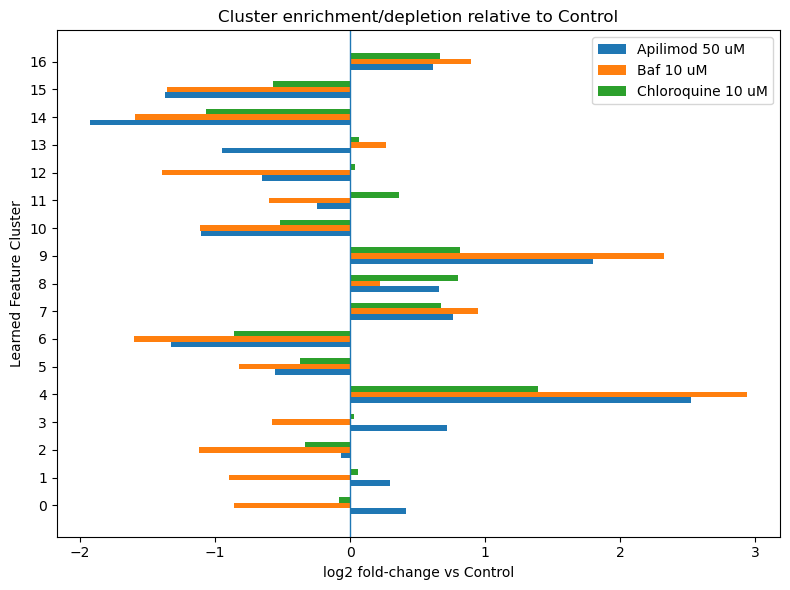

In [12]:
fig, ax, result_df = plot_cluster_enrichment_vs_control(
    df,
    conditiona="Apilimod 50 uM",
    conditionb="Baf 10 uM",
    conditionc='Chloroquine 10 uM',
    cluster_col="Learned Feature Cluster",
)

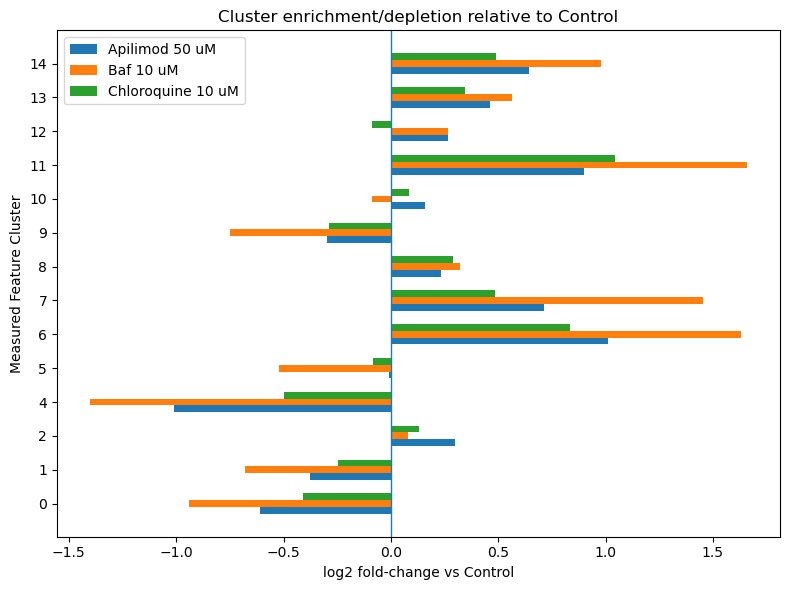

In [13]:
fig, ax, result_df = plot_cluster_enrichment_vs_control(
    df,
    conditiona="Apilimod 50 uM",
    conditionb="Baf 10 uM",
    conditionc='Chloroquine 10 uM',
    cluster_col="Measured Feature Cluster",
)

Cell Level UMAP Data Generation

In [9]:
def make_cell_cluster_count_table(
    df: pd.DataFrame,
    cluster_col,
    cell_id_col: str = "SourceCSV",
    condition_col: Optional[str] = "Condition",
    add_counts: bool = True,
    normalize: bool = False,
    cluster_prefix: str = "cluster_",
) -> pd.DataFrame:

    cluster_col = cluster_col

    if cell_id_col not in df.columns:
        raise ValueError(f"cell_id_col='{cell_id_col}' not in df.columns")

    if cluster_col not in df.columns:
        raise ValueError(f"cluster column '{cluster_col}' not found in df.columns")

    if condition_col is not None and condition_col not in df.columns:
        raise ValueError(f"condition_col='{condition_col}' not in df.columns")

    X = df.copy()
    X[cluster_col] = pd.to_numeric(X[cluster_col], errors="coerce")

    # Count organelles per cell per cluster
    count_table = (
        X.groupby([cell_id_col, cluster_col], dropna=False)
         .size()
         .unstack(fill_value=0)
    )

    # Sort cluster columns numerically where possible
    try:
        count_table = count_table.reindex(sorted(count_table.columns), axis=1)
    except TypeError:
        pass

    # Rename columns to something explicit like cluster_0, cluster_1, ...
    count_table.columns = [f"{cluster_prefix}{int(c)}" if pd.notna(c) else f"{cluster_prefix}nan"
                           for c in count_table.columns]

    if normalize:
        row_sums = count_table.sum(axis=1)
        count_table = count_table.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    cell_df = count_table.reset_index()

    # Attach condition metadata
    if condition_col is not None:
        grouped = X.groupby(cell_id_col, dropna=False)
        cond = grouped[condition_col].agg(
            lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan
        ).reset_index()
        cell_df = cell_df.merge(cond, on=cell_id_col, how="left")

    # Attach total organelle count
    if add_counts:
        counts = X.groupby(cell_id_col, dropna=False).size().rename("OrganelleCount").reset_index()
        cell_df = cell_df.merge(counts, on=cell_id_col, how="left")

    return cell_df

def fit_umap_on_dataframe(
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    *,
    filename_col: str = "SourceCSV",
    n_components: int = 2,
    scale: bool = True,
    drop_nan_rows: bool = True,
    # Common UMAP knobs:
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    metric: str = "euclidean",
    random_state: Optional[int] = 0,
    ) -> Dict[str, Any]:
    """
    Fit UMAP on full dataset using selected columns.

    Returns a dict with:
      - 'umap_model': fitted UMAP object
      - 'scaler': fitted StandardScaler or None
      - 'feature_cols': columns used
      - 'fit_index': index of rows used (NaN rows dropped if enabled)
      - 'embedding': DataFrame with UMAP1..UMAPk for fit rows
    """
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"These feature_cols are not in df.columns: {missing}")

    X = df.loc[:, feature_cols].copy()
    for c in feature_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    if drop_nan_rows:
        valid_mask = ~X.isna().any(axis=1)
    else:
        valid_mask = np.ones(len(X), dtype=bool)

    fit_df = df.loc[valid_mask].copy()
    X_fit = X.loc[valid_mask].to_numpy(dtype=float)

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(X_fit)

    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    emb = umap_model.fit_transform(X_fit)

    emb_cols = [f"UMAP{i+1}" for i in range(emb.shape[1])]
    embedding = pd.DataFrame(emb, columns=emb_cols, index=fit_df.index)

    return {
        "umap_model": umap_model,
        "scaler": scaler,
        "feature_cols": feature_cols,
        "fit_index": fit_df.index,
        "embedding": embedding,
        "filename_col": filename_col,
        "scale": scale,
        "drop_nan_rows": drop_nan_rows,
        "umap_params": {
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "metric": metric,
            "n_components": n_components,
            "random_state": random_state,
        },
    }


def get_umap_embedding_for_plotting(
    df: pd.DataFrame,
    umap_bundle: Dict[str, Any],
    *,
    prefixes: Optional[Union[str, Sequence[str]]] = None,
    filename_col: Optional[str] = None,
) -> pd.DataFrame:
    """
    Join UMAP coordinates onto df (for rows used in fit), and optionally filter by
    filename prefix(es) for plotting.
    """

    base = df.loc[umap_bundle["fit_index"]].copy()
    out = base.join(umap_bundle["embedding"], how="inner")

    if prefixes is not None:
        if isinstance(prefixes, str):
            prefixes = [prefixes]
        prefixes = prefixes

        if filename_col is None:
            filename_col = umap_bundle.get("filename_col", "SourceCSV")
    
        if filename_col not in df.columns:
            raise ValueError(f"filename_col='{filename_col}' not found in df.columns")

        # If the filename column is a path, match on basename
        names = out[filename_col].astype(str).map(lambda s: s.split("\\")[-1].split("/")[-1])

        mask = np.zeros(len(out), dtype=bool)
        for pref in prefixes:
            mask |= names.str.startswith(pref)
        out = out.loc[mask].copy()

    return out

def plot_embedding_scatter(
    plot_df: pd.DataFrame,
    *,
    x: str = "UMAP1",
    y: str = "UMAP2",
    label_col: str | None = None,
    color_col: str | None = None,          # <-- NEW: heatmap coloring by a feature column
    cmap: str = "viridis",                 # <-- NEW: colormap for continuous coloring
    vmin: float | None = None,             # <-- NEW: clamp lower range
    vmax: float | None = None,             # <-- NEW: clamp upper range
    colorbar: bool = False,                 # <-- NEW: show colorbar for continuous coloring
    title: str | None = None,
    alpha_all: float = 0.25,
    alpha_label: float = 0.85,
    s_all: float = 10,
    s_label: float = 18,
    overlay_labeled_on_all: bool = False,
    show_legend: bool = True,
):
    """
    Scatter plot for embedding coordinates (UMAP/PCA/etc).

    Modes:
      1) color_col is provided (continuous "heatmap" coloring):
         - Points are colored by plot_df[color_col] (must be numeric).
         - If overlay_labeled_on_all is True and label_col is provided:
             background = all points faint gray
             foreground = labeled points colored by color_col
         - Otherwise:
             all points colored by color_col
         - Adds a colorbar (optional).

      2) color_col is None:
         Behaves like the original function: either single-color, or grouped colors by label_col.

    Notes:
      - Uses matplotlib defaults for categorical colors (labels).
      - Uses `cmap` for continuous coloring.
    """
    if x not in plot_df.columns or y not in plot_df.columns:
        raise ValueError(f"plot_df must contain columns '{x}' and '{y}'")

    if label_col is not None and label_col not in plot_df.columns:
        raise ValueError(f"label_col='{label_col}' not found in plot_df.columns")

    if color_col is not None and color_col not in plot_df.columns:
        raise ValueError(f"color_col='{color_col}' not found in plot_df.columns")

    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if title:
        ax.set_title(title)

    # -----------------------------
    # Continuous "heatmap" coloring
    # -----------------------------
    if color_col is not None:
        vals = plot_df[color_col]

        # Require numeric (common gotcha: object dtype)
        if not pd.api.types.is_numeric_dtype(vals):
            raise ValueError(
                f"color_col='{color_col}' must be numeric (got dtype={vals.dtype}). "
                f"If it's a string column, use label_col instead."
            )

        # Matplotlib can't color NaNs well; we'll mask them out.
        valid_mask = vals.notna() & np.isfinite(vals.to_numpy(dtype=float, copy=False))

        # If overlaying labeled-on-all, make a faint gray background
        if overlay_labeled_on_all and (label_col is not None):
            ax.scatter(plot_df[x], plot_df[y], alpha=alpha_all, s=s_all, c="k")

            labeled_mask = (~plot_df[label_col].isna())
            fg_mask = labeled_mask & valid_mask

            sc = ax.scatter(
                plot_df.loc[fg_mask, x],
                plot_df.loc[fg_mask, y],
                c=plot_df.loc[fg_mask, color_col],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha_label,
                s=s_label,
            )

            # optional legend for label groups (as outlines), without overriding heatmap colors
            if show_legend and labeled_mask.any():
                for lab, sub in plot_df.loc[labeled_mask].groupby(label_col, dropna=False):
                    ax.scatter(
                        sub[x], sub[y],
                        s=s_label,
                        facecolors="none",
                        edgecolors="k",
                        linewidths=0.6,
                        alpha=min(1.0, alpha_label + 0.1),
                        label=str(lab),
                    )
                ax.legend(title=label_col, loc="best", frameon=True)

        else:
            # Color all points by the feature (gray for NaNs)
            # Plot NaNs first so colored points sit on top
            nan_mask = ~valid_mask
            if nan_mask.any():
                ax.scatter(
                    plot_df.loc[nan_mask, x],
                    plot_df.loc[nan_mask, y],
                    alpha=alpha_all,
                    s=s_all,
                    c="lightgray",
                )

            sc = ax.scatter(
                plot_df.loc[valid_mask, x],
                plot_df.loc[valid_mask, y],
                c=plot_df.loc[valid_mask, color_col],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha_label,
                s=s_label,
            )

            # If user also wants label legend (use outlines so we don't ruin the colormap)
            if label_col is not None and show_legend:
                for lab, sub in plot_df.loc[~plot_df[label_col].isna()].groupby(label_col, dropna=False):
                    ax.scatter(
                        sub[x], sub[y],
                        s=s_label,
                        facecolors="none",
                        edgecolors="k",
                        linewidths=0.6,
                        alpha=min(1.0, alpha_label + 0.1),
                        label=str(lab),
                    )
                ax.legend(title=label_col, loc="best", frameon=True)

        if colorbar:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label(color_col)

        plt.show()
        return fig, ax

    # -----------------------------
    # Original categorical behavior
    # -----------------------------

    # Case 1: no labels -> single-color plot, no legend
    if label_col is None:
        ax.scatter(plot_df[x], plot_df[y], alpha=alpha_label, s=s_label)
        plt.show()
        return fig, ax

    # Case 2: overlay labeled subset on all points
    if overlay_labeled_on_all:
        ax.scatter(plot_df[x], plot_df[y], alpha=alpha_all, s=s_all)

        labeled = plot_df.loc[~plot_df[label_col].isna()].copy()
        for label, sub in labeled.groupby(label_col, dropna=False):
            ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label))

        if show_legend and len(labeled) > 0:
            ax.legend(title=label_col, loc="best", frameon=True)

        plt.show()
        return fig, ax

    # Case 3: label everything by group
    # for label, sub in plot_df.groupby(label_col, dropna=False):
    #     ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label))
    colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
    "gold",
    "navy",
    "magenta",
    ]

    for i, (label, sub) in enumerate(plot_df.groupby(label_col, dropna=False)):
        ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label), color=colors[i % len(colors)])
    
    if show_legend:
        ax.legend(title=label_col, loc="best", frameon=True)

    plt.show()
    return fig, ax

In [7]:
clust_cell_df_deep = make_cell_cluster_count_table(df, 'Learned Feature Cluster', normalize=True)
clust_cell_df_fof = make_cell_cluster_count_table(df, 'Measured Feature Cluster', normalize=True)
clust_cell_df_deep = clust_cell_df_deep[clust_cell_df_deep["OrganelleCount"] > 40]
clust_cell_df_fof = clust_cell_df_fof[clust_cell_df_fof["OrganelleCount"] > 40]

/net/bmc-lab8/data/lab/boyer/users/jhday/conda/envs/inference_data/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


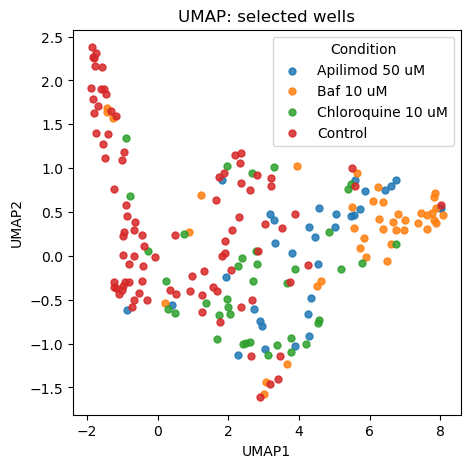

In [10]:
feats = [f'cluster_{k}' for k in range(15)]
conditionset = ["Control","Baf 100 nM","Baf 10 uM","Chloroquine 100 nM","Chloroquine 10 uM","Apilimod 500 nM","Apilimod 50 uM"]

ccdf = clust_cell_df_deep[~clust_cell_df_deep["Condition"].str.contains("nM", na=False)]
ccdf = ccdf[ccdf['Condition'].isin(conditionset)]

umap_bundle = fit_umap_on_dataframe(
    ccdf,
    feats,
    n_components=2,
    scale=False,
    n_neighbors=20,
    min_dist=0.05,
    random_state=0,
)

plot_df = get_umap_embedding_for_plotting(
    ccdf,
    umap_bundle,
)

figure,axes=plot_embedding_scatter(plot_df, x="UMAP1", y="UMAP2", cmap='inferno', label_col='Condition', show_legend=True, title="UMAP: selected wells", s_all=25, s_label=25)